# SI: Single-Dye Photobleaching

Reads a `Single_frame_database.h5` for a chosen dye, screens molecules for
single-step photobleaching, and produces a 3 × 3 panel figure.  
Intensity traces are extracted from the **raw Bayer image** (12 × 12 pixel ROI,
converted to photoelectrons) so that background levels are visible alongside
the bleaching step.

**Workflow**
1. Pre-filter molecules by minimum detected-frame count.
2. For each candidate, extract the ROI intensity trace from the raw TIFF stack.
3. Run PELT change-point detection (same algorithm as the FRET analysis).
4. Classify as single-step if exactly one downward step is found.
5. Collect the first `N_FIGURE` passing candidates and plot.

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import gc
from pathlib import Path
from tqdm import tqdm

import sys
sys.path.append('../../..')

from src import IOFunctions
from src import sCMOSFunctions
from src import HelperFunctions
from src.StepDetector import StepDetector
from src import PlottingFunctions

IO     = IOFunctions.IO_Functions()
sCMOS  = sCMOSFunctions.sCMOS_Functions()
Helper = HelperFunctions.Helper_Functions()
plotter = PlottingFunctions.Plotter()

/tmp/ipykernel_1655261/3070445361.py:21: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


## Camera calibration

In [63]:
cal_dir = Path('../../../Camera_Calibrations/Ximea_Camera/')

gain    = IO.read_tiff(str(cal_dir / 'gain.tif'))
offset  = IO.read_tiff(str(cal_dir / 'offset.tif'))
rqe     = IO.read_tiff(str(cal_dir / 'rqe.tif'))
read_noise = IO.read_tiff(str(cal_dir / 'readnoise.tif'))
variance = IO.read_tiff(str(cal_dir / 'variance.tif'))


print(f'Calibration maps loaded — shape: {gain.shape}')

Calibration maps loaded — shape: (1544, 2064)


## Data configuration

Edit `dye_config` to point at the dyes you want to include.
Each entry maps a label to a `(Single_frame_database path, raw TIFF folder)` tuple.  
The raw folder must sit inside the same dye directory and contain the `.ome.tif` files
that were used to build the database.

In [137]:
SMB_BASE = Path('/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/Single_Dye_Experiments')

dye_config = {
    'ATTO488':  (SMB_BASE / 'ATTO488/Single_frame_database.h5',
                 SMB_BASE / 'ATTO488/40mW488_488LP_BP520-44_1'),
    'ATTO514':  (SMB_BASE / 'ATTO514/Single_frame_database.h5',
                 SMB_BASE / 'ATTO514/30p_515_LP515_BP540_80_1'),
    'ATTO520':  (SMB_BASE / 'ATTO520/Single_frame_database.h5',
                 SMB_BASE / 'ATTO520/30p_515_LP515_BP540_80_1'),
    'ATTO565':  (SMB_BASE / 'ATTO565/Single_frame_database.h5',
                 SMB_BASE / 'ATTO565/20perc_561_LP561_BP582-64_1'),
    'ATTO594':  (SMB_BASE / 'ATTO594/Single_frame_database.h5',
                 SMB_BASE / 'ATTO594/40p_NF_785SP_1_488_561dichro'),
    'ATTO620':  (SMB_BASE / 'ATTO620/Single_frame_database.h5',
                 SMB_BASE / 'ATTO620/40per_638_1_635LP_1'),
    'ATTO633':  (SMB_BASE / 'ATTO633/Single_frame_database.h5',
                 SMB_BASE / 'ATTO633/40both638_NF_785SP_1'),
    'ATTO647N': (SMB_BASE / 'ATTO647N/Single_frame_database.h5',
                 SMB_BASE / 'ATTO647N/40both638_NF_785SP_1'),
    'ATTO655':  (SMB_BASE / 'ATTO655/Single_frame_database.h5',
                 SMB_BASE / 'ATTO655/40both638_NF_785SP_1'),
    'ATTO700':  (SMB_BASE / 'ATTO700/Single_frame_database.h5',
                 SMB_BASE / 'ATTO700/40mW638_both_NF_785sp_1'),
    'ATTORho6G':(SMB_BASE / 'ATTORho6G/Single_frame_database.h5',
                 SMB_BASE / 'ATTORho6G/30p_515_LP515_1'),
}

# --- parameters ---
chosen_dye   = 'ATTO565'  # which dye to show in the figure

ROI_SIZE      = 12    # pixels; square ROI centred on localisation
MIN_FRAMES    = 12     # minimum detected frames to consider a molecule
PRE_PAD       = 0    # frames before first detection to include in trace
POST_PAD      = 200    # frames after last detection to include in trace
N_FIGURE      = 9     # panels shown in the final figure
N_POOL        = 3     # screen N_FIGURE * N_POOL candidates so spares are available
RANDOM_SEED   = 42

# --- step detector ---
# Watkins & Yang (2005) LR change-point detector with Vostrikova (1982)
# asymptotic threshold. alpha is the false-positive rate per segment:
# decrease to be more conservative, increase to catch smaller steps.
CP_WIN_SIZE = 30     # minimum segment length considered for a split
CP_ALPHA    = 0.01   # false-positive rate per segment (5%)

detector = StepDetector(win_size=CP_WIN_SIZE, alpha=CP_ALPHA)
print(f'StepDetector ready  (win_size={CP_WIN_SIZE}, alpha={CP_ALPHA})')

StepDetector ready  (win_size=30, alpha=0.01)


## Screen molecules for single-step photobleaching

Reads the database for `chosen_dye`, pre-filters by `MIN_FRAMES`, then iterates
through shuffled candidates — extracting the raw ROI trace and running PELT — until
`N_FIGURE` single-step bleachers are found.

In [65]:
db_path, raw_folder = dye_config[chosen_dye]
# --- load database ---
print(f'Loading {db_path.name}  ({chosen_dye})')
db = pd.read_hdf(str(db_path))
if 'level_0' in db.columns:
    db = db.reset_index(drop=True).drop('level_0',axis=1)
print(f'  {len(db):,} localizations, {db["molecular_index"].nunique():,} unique molecules')


Loading Single_frame_database.h5  (ATTO565)
  1,786,259 localizations, 31,222 unique molecules


In [66]:
mol = (
    db.groupby('molecular_index')
    .agg(
        n_frames    = ('frame',   'count'),
        xc_mean     = ('xc',      'mean'),
        yc_mean     = ('yc',      'mean'),
        frame_min   = ('frame',   'min'),
        frame_max   = ('frame',   'max'),
        photons_mean= ('photons', 'mean'),
        fov_name = ('fov_name', 'first'),
    )
    .reset_index()
)


In [67]:
candidates = mol[mol['n_frames'] >= MIN_FRAMES].copy()
print(f'  Candidates with ≥{MIN_FRAMES} frames: {len(candidates):,}')

candidates = candidates.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
relevant_files = np.unique(candidates['fov_name'])

# --- build raw TIFF file index ---
print(f'Indexing TIFF files in {raw_folder.name} ...')
tifs = Helper.file_search(str(raw_folder), ".tif", "")
metadata_files = Helper.file_search(str(raw_folder), "metadata", "")
start_x, start_y, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])
cropped_maps = Helper.crop_calibration_maps(
            {
                "gain_map": gain,
                "offset_map": offset,
                "read_noise": read_noise,
                "rqe": rqe,
                "variance": variance,
            },
            start_x,
            start_y,
            width,
            height,
        )
gain_map_cropped = cropped_maps["gain_map"]
offset_map_cropped = cropped_maps["offset_map"]
read_noise_cropped = cropped_maps["read_noise"]
rqe_cropped = cropped_maps["rqe"]
variance_cropped = cropped_maps["variance"]


  Candidates with ≥12 frames: 29,223
Indexing TIFF files in 20perc_561_LP561_BP582-64_1 ...


In [68]:
raw = IO.read_tiff_tophotoelectrons(tifs[0], dtype='float32', gain_map=gain_map_cropped, offset_map=offset_map_cropped, rqe=rqe_cropped)   # (n_frames, H, W)

In [82]:
current_file = candidates[np.isin(candidates['fov_name'], os.path.split(tifs[0])[-1].split('.')[0])]
current_file = current_file.reset_index()

In [86]:
current_file

,index,molecular_index,n_frames,xc_mean,yc_mean,frame_min,frame_max,photons_mean,fov_name
0,5,1571,15,990.242188,593.400757,593,616,4246.185547,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
1,23,536,154,1025.449829,351.040161,252,669,2204.013916,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
2,40,807,17,70.991211,879.030823,329,357,3213.416260,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
3,55,1500,160,196.724670,174.012070,272,1095,5732.143555,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
4,71,919,17,315.097015,823.134644,420,680,322.627075,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
...,...,...,...,...,...,...,...,...,...
2426,29178,2038,43,913.543701,180.162033,261,381,3385.037354,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
2427,29182,199,35,135.756378,716.962402,269,1113,583.941895,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
2428,29203,838,73,306.882172,1026.372314,250,493,2381.821533,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000
2429,29204,1812,68,752.829346,711.766785,251,419,5768.484375,20perc_561_LP561_BP582-64_1_MMStack_1-Pos000_000


In [115]:
i = 8
FOV_size = 12
lag = 100
x = current_file.xc_mean[i]
y = current_file.yc_mean[i]
xmin = int(x - FOV_size/2)
xmax = int(x + FOV_size/2)
ymin = int(y - FOV_size/2)
ymax = int(y + FOV_size/2)
fmin = int(current_file.frame_min[i])
fmax = int(current_file.frame_max[i] + lag)
image = raw[fmin:fmax, ymin:ymax, xmin:xmax]

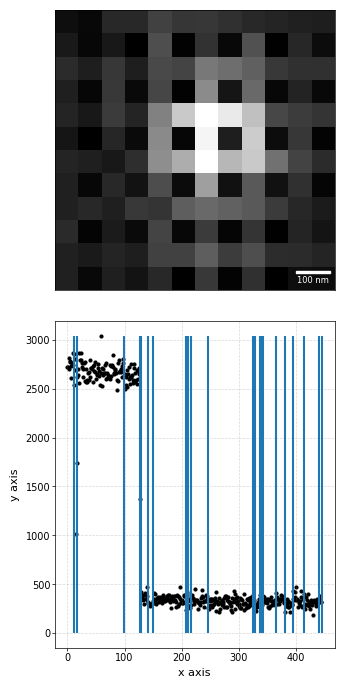

In [138]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1])

axs[0] = plotter.image_plot(axs[0], image[0, :, :], scalebarsize=100, scalebarlabel='100 nm', cbar='off')

y = np.sum(np.sum(image, axis=1), axis=1)
x = np.arange(len(y))
cps = detector.detect(y)
axs[1] = plotter.scatter_plot(axs[1], x, y)
axs[1].vlines(cps, ymin=0, ymax=np.max(y))

In [139]:
cps

[12,
 17,
 99,
 127,
 128,
 141,
 150,
 208,
 209,
 212,
 217,
 246,
 326,
 328,
 337,
 340,
 342,
 365,
 382,
 395,
 415,
 440,
 446]

In [140]:
np.diff(cps)

array([ 5, 82, 28,  1, 13,  9, 58,  1,  3,  5, 29, 80,  2,  9,  3,  2, 23,
       17, 13, 20, 25,  6])

In [55]:
import pandas as pd
from pathlib import Path

KNOWN_SUFFIXES = {'.h5', '.hdf5', '.tif', '.tiff', '.ome', '.txt', '.csv', '.json'}

def strip_fov_name(name: str) -> str:
  p = Path(name)
  while p.suffix.lower() in KNOWN_SUFFIXES:
      p = p.with_suffix('')
  return p.name

def fix_file(path: Path):
  df = pd.read_hdf(path)
  if 'fov_name' not in df.columns:
      print(f'  skipping {path.name} — no fov_name column')
      return
  before = df['fov_name'].iloc[0]
  df['fov_name'] = df['fov_name'].map(strip_fov_name)
  after = df['fov_name'].iloc[0]
  df.to_hdf(path, key='data', mode='w')
  print(f'  {path.name}: "{before}" → "{after}"')

def file_fixer(path):
  import sys
  root = Path(path)
  files = sorted(root.rglob('*.h5'))
  print(f'Found {len(files)} .h5 files under {root}')
  for f in files:
      fix_file(f)

In [ ]:
db_path, raw_folder = dye_config[chosen_dye]
# --- load database ---
print(f'Loading {db_path.name}  ({chosen_dye})')
db = pd.read_hdf(str(db_path))
if 'level_0' in db.columns:
    db = db.reset_index(drop=True).drop('level_0',axis=1)
print(f'  {len(db):,} localizations, {db["molecular_index"].nunique():,} unique molecules')

# --- per-molecule summary ---
mol = (
    db.groupby('molecular_index')
    .agg(
        n_frames    = ('frame',   'count'),
        xc_mean     = ('xc',      'mean'),
        yc_mean     = ('yc',      'mean'),
        frame_min   = ('frame',   'min'),
        frame_max   = ('frame',   'max'),
        photons_mean= ('photons', 'mean'),
        fov_name = ('fov_name', 'first'),
    )
    .reset_index()
)

candidates = mol[mol['n_frames'] >= MIN_FRAMES].copy()
print(f'  Candidates with ≥{MIN_FRAMES} frames: {len(candidates):,}')

candidates = candidates.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
relevant_files = np.unique(candidates['fov_name'])

# --- build raw TIFF file index ---
print(f'Indexing TIFF files in {raw_folder.name} ...')
tifs = Helper.file_search(str(raw_folder), ".tif", "")
metadata_files = Helper.file_search(str(raw_folder), "metadata", "")
start_x, start_y, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])
cropped_maps = Helper.crop_calibration_maps(
            {
                "gain_map": gain,
                "offset_map": offset,
                "read_noise": read_noise,
                "rqe": rqe,
                "variance": variance,
            },
            start_x,
            start_y,
            width,
            height,
        )
gain_map_cropped = cropped_maps["gain_map"]
offset_map_cropped = cropped_maps["offset_map"]
read_noise_cropped = cropped_maps["read_noise"]
rqe_cropped = cropped_maps["rqe"]
variance_cropped = cropped_maps["variance"]

# --- pre-compute frame ranges and pre-allocate trace arrays ---
# Each candidate gets a float32 trace pre-filled with zeros; portions are
# filled in as each TIFF file is loaded once.
n_target = N_FIGURE * N_POOL
half = ROI_SIZE // 2
cand_info = []
for _, row in candidates.iterrows():
    f0 = max(0,            int(row['frame_min']) - PRE_PAD)
    f1 = min(total_frames, int(row['frame_max']) + POST_PAD + 1)
    xpx = int(round(row['xc_mean']))
    ypx = int(round(row['yc_mean']))
    cand_info.append({
        'mol_index': int(row['molecular_index']),
        'xc':  row['xc_mean'],
        'yc':  row['yc_mean'],
        'xpx': xpx, 'ypx': ypx,
        'f0':  f0,  'f1':  f1,
        'trace': np.zeros(f1 - f0, dtype=np.float32),
    })

# --- load each TIFF file once; fill all overlapping traces in memory ---
for fi, tif in enumerate(tqdm(tifs, desc='Loading TIFF files')):
    file_start = int(cum_offsets[fi])
    file_end   = int(cum_offsets[fi + 1])

    relevant = [c for c in cand_info
                if c['f0'] < file_end and c['f1'] > file_start]
    if not relevant:
        continue

    raw = IO.read_tiff_tophotoelectrons(str(tif), dtype='float32', gain_map=gain_map_cropped, offset_map=offset_map_cropped,
                                       rqe=rqe_cropped)   # (n_frames, H, W)
    if raw.ndim == 2:
        raw = raw[np.newaxis]

    for c in relevant:
        lo = max(c['f0'], file_start)
        hi = min(c['f1'], file_end)
        x0, x1 = max(0, c['xpx'] - half), c['xpx'] + half
        y0, y1 = max(0, c['ypx'] - half), c['ypx'] + half

        pe = raw[lo - file_start : hi - file_start, y0:y1, x0:x1]
        c['trace'][lo - c['f0'] : hi - c['f0']] = pe.sum(axis=(1, 2))

    del raw
    gc.collect()

# --- detect change points and filter ---
# Keep molecules with exactly one CP (single bleaching step).
# Collect N_FIGURE * N_POOL so spares are available if any look poor visually.
found = []
for c in tqdm(cand_info, desc='Detecting'):
    cps = detector.detect(c['trace'])
    if len(cps) == 2:   # exactly one internal CP + terminal index
        found.append(dict(
            mol_index = c['mol_index'],
            xc        = c['xc'],
            yc        = c['yc'],
            f0        = c['f0'],
            trace     = c['trace'],
            cps       = cps,
        ))
    if len(found) >= n_target:
        break

print(f'\nFound {len(found)} single-step photobleaching molecules '
      f'(showing first {N_FIGURE}, {len(found) - N_FIGURE} spares available).')

## 3 × 3 figure

In [ ]:
n_cols = 3
n_rows = (N_FIGURE + n_cols - 1) // n_cols

fig, axs = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.2, n_rows * 1.7),
    constrained_layout=True,
)
axs = axs.ravel()

for i, cand in enumerate(found[:N_FIGURE]):
    ax    = axs[i]
    trace = cand['trace']
    cps   = cand['cps']
    f0    = cand['f0']
    frames = np.arange(f0, f0 + len(trace))
    means  = detector.segment_means(trace, cps)

    # raw trace
    ax.plot(frames, trace, color='#aaaaaa', lw=0.5, alpha=0.9, zorder=1)
    # segment means
    ax.plot(frames, means, color='#d40000', lw=1.1, zorder=2)
    # change-point locations
    for cp in cps[:-1]:
        ax.axvline(f0 + cp, color='#d40000', lw=0.8, ls='--', alpha=0.6, zorder=3)

    ax.set_xlim(frames[0], frames[-1])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=6, length=2, pad=1)

    row_idx = i // n_cols
    col_idx = i %  n_cols
    if col_idx == 0:
        ax.set_ylabel('Intensity / pe', fontsize=6)
    if row_idx == n_rows - 1:
        ax.set_xlabel('Frame', fontsize=6)

# hide unused panels
for j in range(len(found), len(axs)):
    axs[j].set_visible(False)

fig.suptitle(f'{chosen_dye} — single-step photobleaching ({ROI_SIZE}×{ROI_SIZE} px ROI)',
             fontsize=8)

fig_path = Path('../../../Papers/Multicolour/SI/SI_Single_Dye_Photobleaching.svg')
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=300, format='svg', bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## (Optional) Quick-look: single molecule

Inspect one candidate interactively before committing to the figure.

In [ ]:
idx = -2  # which candidate to inspect
cand  = found[idx]
trace = cand['trace']
cps   = cand['cps']
f0    = cand['f0']
frames = np.arange(f0, f0 + len(trace))

print(f"Molecule index: {cand['mol_index']}")
print(f"Position: xc={cand['xc']:.1f}, yc={cand['yc']:.1f} px")
print(f"Frame range: {f0} – {f0 + len(trace)}")
print(f"Change points: {cps}")
print(f"Segment means: {[float(f'{np.nanmean(trace[p:q]):.0f}') for p, q in zip([0]+cps[:-1], cps)]}")

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.plot(frames, trace, color='#aaaaaa', lw=0.6)
ax.plot(frames, detector.segment_means(trace, cps), color='#d40000', lw=1.2)
for cp in cps[:-1]:
    ax.axvline(f0 + cp, color='#d40000', lw=1, ls='--', alpha=0.7)
ax.set_xlabel('Frame')
ax.set_ylabel('Intensity / pe')
ax.set_ylim(bottom=0)
ax.set_title(f"{chosen_dye}  mol {cand['mol_index']}  CPs={cps[:-1]}")
plt.tight_layout()
plt.show()